SOME NECESSARY LIBRARIES

In [3]:
import google.colab
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install xgboost
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler

ModuleNotFoundError: No module named 'catboost'

1. Briefly about the dataset

In [ ]:
du_lieu_giao_thong = pd.read_csv('dataset_traffic_accident_prediction1.csv')
du_lieu_giao_thong

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Clear,Highway,Night,2.0,30.0,4.0,0.0,Low,Dry,Car,23.0,15.0,Daylight,0.0
836,Rainy,Rural Road,Evening,2.0,60.0,4.0,0.0,Low,Dry,Motorcycle,52.0,46.0,Daylight,1.0
837,Foggy,Highway,Evening,NaN,30.0,4.0,1.0,High,Dry,Car,NaN,34.0,Artificial Light,NaN
838,Foggy,Highway,Afternoon,2.0,60.0,3.0,0.0,Low,Dry,Car,25.0,19.0,Artificial Light,0.0


In [ ]:
du_lieu_giao_thong.describe()

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1.001253,71.050125,3.286967,0.160401,43.259398,38.981203,0.299499
std,0.784894,32.052458,2.017267,0.367208,15.129856,15.273201,0.458326
min,0.000000,30.000000,1.000000,0.000000,18.000000,9.000000,0.000000
25%,0.000000,50.000000,2.000000,0.000000,30.000000,26.000000,0.000000
50%,1.000000,60.000000,3.000000,0.000000,43.000000,39.000000,0.000000
75%,2.000000,80.000000,4.000000,0.000000,56.000000,52.750000,1.000000
max,2.000000,213.000000,14.000000,1.000000,69.000000,69.000000,1.000000


In [ ]:
du_lieu_giao_thong.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    object 
 1   Road_Type             798 non-null    object 
 2   Time_of_Day           798 non-null    object 
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    object 
 8   Road_Condition        798 non-null    object 
 9   Vehicle_Type          798 non-null    object 
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    object 
 13  Accident              798 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


2. Processing missing value

In [ ]:
du_lieu_giao_thong.isnull().sum()

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64

NUMERICAL VARIABLES

Traffic_Density - Mean: 1.0012531328320802, Меdian: 1.0


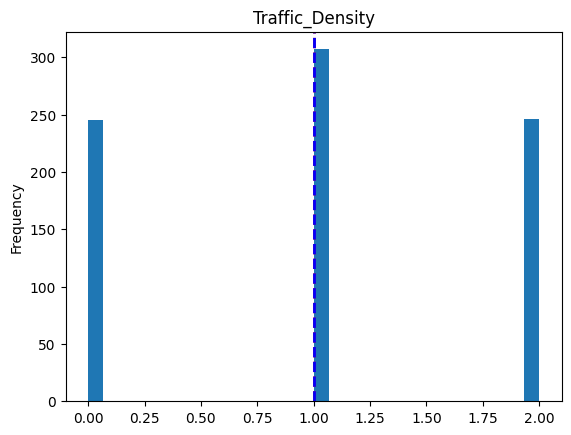

Speed_Limit - Mean: 71.0501253132832, Меdian: 60.0


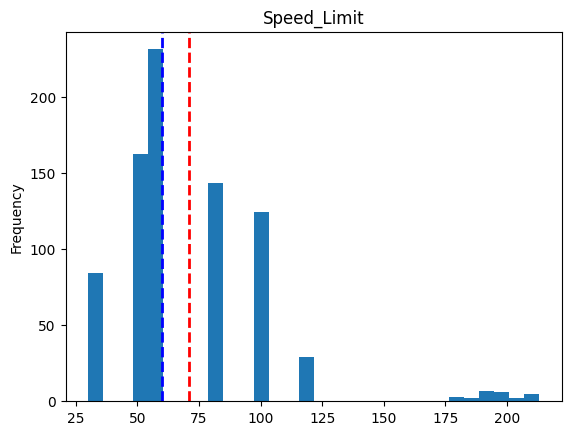

Number_of_Vehicles - Mean: 3.2869674185463658, Меdian: 3.0


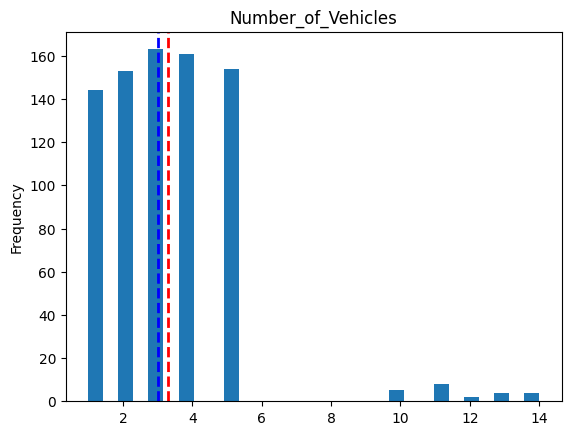

Driver_Alcohol - Mean: 0.16040100250626566, Меdian: 0.0


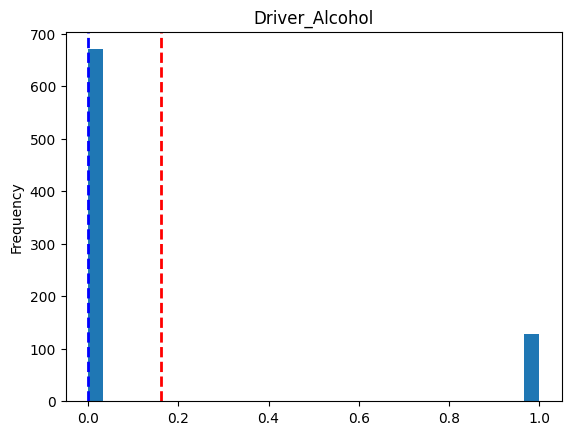

Driver_Age - Mean: 43.2593984962406, Меdian: 43.0


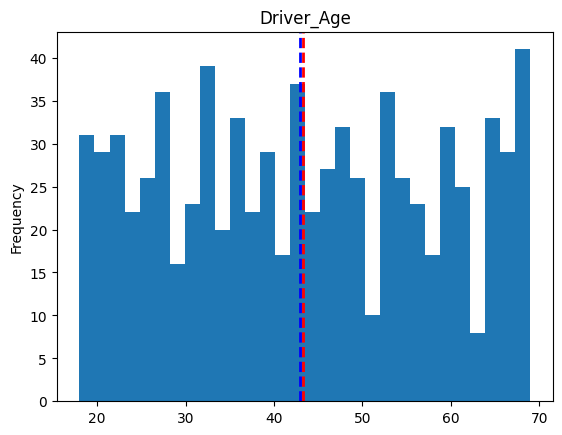

Driver_Experience - Mean: 38.9812030075188, Меdian: 39.0


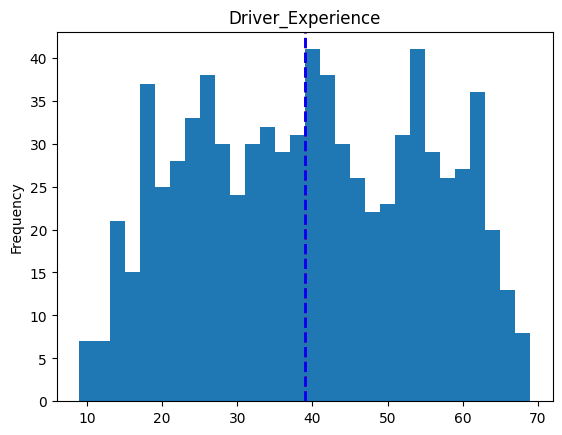

Accident - Mean: 0.29949874686716793, Меdian: 0.0


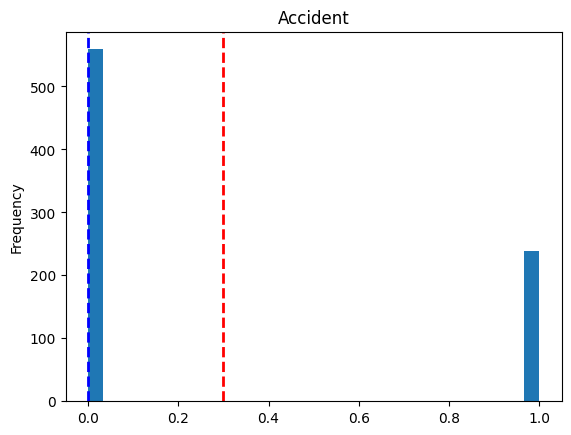

In [ ]:
#considering the numerical variable
columns_with_missing = ['Traffic_Density', 'Speed_Limit', 'Number_of_Vehicles', 'Driver_Alcohol',
                       'Driver_Age', 'Driver_Experience',
                       'Accident']
#checking mean and median for each variables

for i in columns_with_missing:
    print(f"{i} - Mean: {du_lieu_giao_thong[i].mean()}, Меdian: {du_lieu_giao_thong[i].median()}")
    du_lieu_giao_thong[i].plot(kind='hist', bins=30, title=i)
    plt.axvline(du_lieu_giao_thong[i].mean(), color='red', linestyle='dashed', linewidth=2)
    plt.axvline(du_lieu_giao_thong[i].median(), color='blue', linestyle='dashed', linewidth=2)
    plt.show()

In [ ]:
#Replacing the missing value by the median of this columns variables
du_lieu_giao_thong['Traffic_Density'].fillna(du_lieu_giao_thong['Traffic_Density'].median(), inplace=True)
du_lieu_giao_thong['Speed_Limit'].fillna(du_lieu_giao_thong['Speed_Limit'].median(), inplace=True)
du_lieu_giao_thong['Number_of_Vehicles'].fillna(du_lieu_giao_thong['Number_of_Vehicles'].median(), inplace=True)
du_lieu_giao_thong['Driver_Alcohol'].fillna(du_lieu_giao_thong['Driver_Alcohol'].median(), inplace=True)
du_lieu_giao_thong['Driver_Age'].fillna(du_lieu_giao_thong['Driver_Age'].median(), inplace=True)
du_lieu_giao_thong['Driver_Experience'].fillna(du_lieu_giao_thong['Driver_Experience'].median(), inplace=True)
du_lieu_giao_thong['Accident'].fillna(du_lieu_giao_thong['Accident'].median(), inplace=True)

ABOUT THE STRING VARIABLES

In [ ]:
columns_miss = du_lieu_giao_thong.columns[du_lieu_giao_thong.isnull().sum() > 0]
du_lieu_giao_thong[columns_miss].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Weather               798 non-null    object
 1   Road_Type             798 non-null    object
 2   Time_of_Day           798 non-null    object
 3   Accident_Severity     798 non-null    object
 4   Road_Condition        798 non-null    object
 5   Vehicle_Type          798 non-null    object
 6   Road_Light_Condition  798 non-null    object
dtypes: object(7)
memory usage: 46.1+ KB


In [ ]:
du_lieu_giao_thong['Weather'] = du_lieu_giao_thong['Weather'].fillna(du_lieu_giao_thong['Weather'].mode()[0])
du_lieu_giao_thong['Road_Type'] = du_lieu_giao_thong['Road_Type'].fillna(du_lieu_giao_thong['Road_Type'].mode()[0])
du_lieu_giao_thong['Time_of_Day'] = du_lieu_giao_thong['Time_of_Day'].fillna(du_lieu_giao_thong['Time_of_Day'].mode()[0])
du_lieu_giao_thong['Accident_Severity'] = du_lieu_giao_thong['Accident_Severity'].fillna(du_lieu_giao_thong['Accident_Severity'].mode()[0])
du_lieu_giao_thong['Road_Condition'] = du_lieu_giao_thong['Road_Condition'].fillna(du_lieu_giao_thong['Road_Condition'].mode()[0])
du_lieu_giao_thong['Vehicle_Type'] = du_lieu_giao_thong['Vehicle_Type'].fillna(du_lieu_giao_thong['Vehicle_Type'].mode()[0])
du_lieu_giao_thong['Road_Light_Condition'] = du_lieu_giao_thong['Road_Light_Condition'].fillna(du_lieu_giao_thong['Road_Light_Condition'].mode()[0])

AFTER THE PROCESSING ALL MISSING VALUES

In [ ]:
du_lieu_giao_thong.isnull().sum()

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density          0
Speed_Limit              0
Number_of_Vehicles       0
Driver_Alcohol           0
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age               0
Driver_Experience        0
Road_Light_Condition    42
Accident                 0
dtype: int64

In [ ]:
du_lieu_giao_thong

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,1.0,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Clear,Highway,Night,2.0,30.0,4.0,0.0,Low,Dry,Car,23.0,15.0,Daylight,0.0
836,Rainy,Rural Road,Evening,2.0,60.0,4.0,0.0,Low,Dry,Motorcycle,52.0,46.0,Daylight,1.0
837,Foggy,Highway,Evening,1.0,30.0,4.0,1.0,High,Dry,Car,43.0,34.0,Artificial Light,0.0
838,Foggy,Highway,Afternoon,2.0,60.0,3.0,0.0,Low,Dry,Car,25.0,19.0,Artificial Light,0.0


DUPLICATES

In [ ]:
duplicates_count = du_lieu_giao_thong.duplicated().sum()
print(f'Number of duplicates: {duplicates_count}')

Number of duplicates: 15


In [ ]:
#Show some duplicated rows
dup_all = du_lieu_giao_thong[du_lieu_giao_thong.duplicated()]
dup_all

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
261,Rainy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Under Construction,Car,65.0,60.0,Daylight,0.0
270,Snowy,Highway,Morning,2.0,60.0,4.0,0.0,Low,Wet,Car,50.0,43.0,Daylight,1.0
274,Clear,Highway,Afternoon,0.0,60.0,4.0,0.0,High,Icy,Car,19.0,15.0,Artificial Light,0.0
292,Clear,Highway,Morning,1.0,60.0,3.0,0.0,Low,Icy,Car,65.0,57.0,Artificial Light,1.0
410,Clear,City Road,Morning,2.0,50.0,1.0,0.0,Low,Dry,Car,62.0,53.0,Artificial Light,1.0
431,Clear,Highway,Morning,2.0,100.0,2.0,0.0,Low,Dry,Car,48.0,43.0,Daylight,0.0
440,Clear,City Road,Morning,2.0,50.0,1.0,0.0,Low,Dry,Car,67.0,66.0,Artificial Light,0.0
446,Clear,Highway,Afternoon,0.0,60.0,1.0,0.0,Moderate,Icy,Car,56.0,55.0,Daylight,0.0
487,Rainy,City Road,NaN,0.0,60.0,5.0,0.0,Moderate,Wet,Car,48.0,41.0,Daylight,0.0
528,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0


In [ ]:
du_lieu_giao_thong_done = du_lieu_giao_thong.drop_duplicates()
du_lieu_giao_thong_done

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,1.0,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,Clear,Highway,Night,2.0,30.0,4.0,0.0,Low,Dry,Car,23.0,15.0,Daylight,0.0
836,Rainy,Rural Road,Evening,2.0,60.0,4.0,0.0,Low,Dry,Motorcycle,52.0,46.0,Daylight,1.0
837,Foggy,Highway,Evening,1.0,30.0,4.0,1.0,High,Dry,Car,43.0,34.0,Artificial Light,0.0
838,Foggy,Highway,Afternoon,2.0,60.0,3.0,0.0,Low,Dry,Car,25.0,19.0,Artificial Light,0.0


SPEARMAN CORRELATION

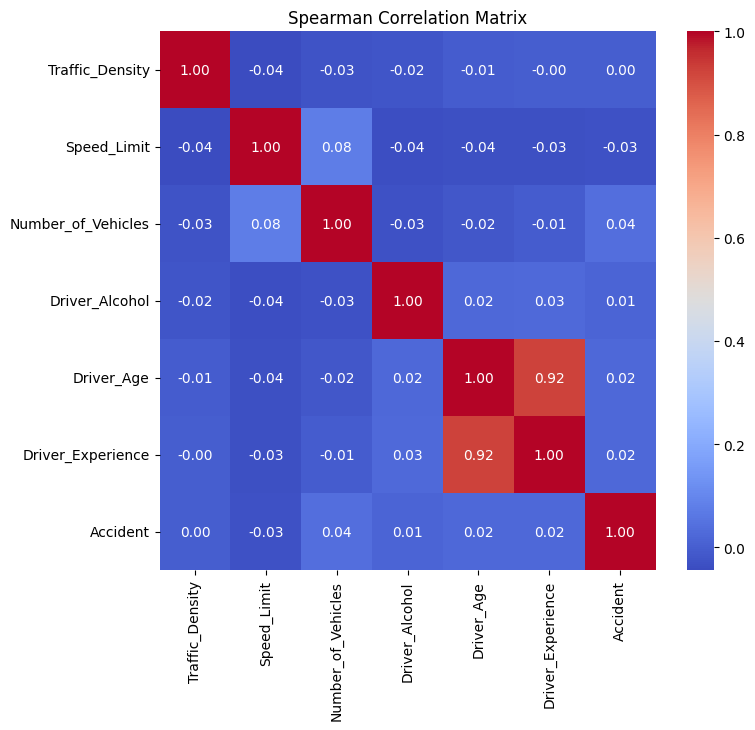

In [ ]:
numeric_df = du_lieu_giao_thong_done.select_dtypes(include=['number'])
spearman_corr = numeric_df.corr(method='spearman')

#heatmap for correlation matrix
plt.figure(figsize=(8, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Matrix')
plt.show()

IMPORTANT STEP:
    Using the 'get_dummies()' function converts categorical variables into dummy/indicator variables. This method is especially useful when preparing data for machine learning algorithms that require numeric input.

In [ ]:
du_lieu_giao_thong_done = pd.get_dummies(du_lieu_giao_thong_done, columns=['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity',
                                  'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition'], drop_first=True)

KeyError: "None of [Index(['Weather', 'Road_Type', 'Time_of_Day', 'Accident_Severity',\n       'Road_Condition', 'Vehicle_Type', 'Road_Light_Condition'],\n      dtype='object')] are in the [columns]"

In [ ]:
du_lieu_giao_thong_done

,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Driver_Age,Driver_Experience,Accident,Weather_Foggy,Weather_Rainy,Weather_Snowy,...,Accident_Severity_Low,Accident_Severity_Moderate,Road_Condition_Icy,Road_Condition_Under Construction,Road_Condition_Wet,Vehicle_Type_Car,Vehicle_Type_Motorcycle,Vehicle_Type_Truck,Road_Light_Condition_Daylight,Road_Light_Condition_No Light
0,1.0,100.0,5.0,0.0,51.0,48.0,0.0,False,True,False,...,False,False,False,False,True,True,False,False,False,False
1,1.0,120.0,3.0,0.0,49.0,43.0,0.0,False,False,False,...,False,True,False,False,True,False,False,True,False,False
2,1.0,60.0,4.0,0.0,54.0,52.0,0.0,False,True,False,...,True,False,True,False,False,True,False,False,False,False
3,2.0,60.0,3.0,0.0,34.0,31.0,0.0,False,False,False,...,True,False,False,True,False,False,False,False,True,False
4,1.0,195.0,11.0,0.0,62.0,55.0,1.0,False,True,False,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,2.0,30.0,4.0,0.0,23.0,15.0,0.0,False,False,False,...,True,False,False,False,False,True,False,False,True,False
836,2.0,60.0,4.0,0.0,52.0,46.0,1.0,False,True,False,...,True,False,False,False,False,False,True,False,True,False
837,1.0,30.0,4.0,1.0,43.0,34.0,0.0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
838,2.0,60.0,3.0,0.0,25.0,19.0,0.0,True,False,False,...,True,False,False,False,False,True,False,False,False,False


In [ ]:
du_lieu_giao_thong_done['Age_vs_Experience'] = du_lieu_giao_thong_done['Driver_Age'] - du_lieu_giao_thong_done['Driver_Experience']
du_lieu_giao_thong_done = du_lieu_giao_thong_done.drop(['Driver_Age', 'Driver_Experience'], axis = 1)

KeyError: 'Driver_Age'

BUILD THE MACHINE LEARNING MODEL:
 - XGBOOST
 - RANDOM FOREST
 - KNN